# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [49]:
import numpy as np
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# STATSMODELS
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.graphics.factorplots import interaction_plot

# SKLEARN
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_log_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# TORCH
import torch
import torch.nn as nn #neural networks
import torch.nn.functional as F # activation functions
import torch.optim as optim #optimisers
from torch.utils.data import DataLoader, TensorDataset

import os

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [50]:
data = pd.read_csv('data/train.csv')
train = data.copy()
test = pd.read_csv('data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


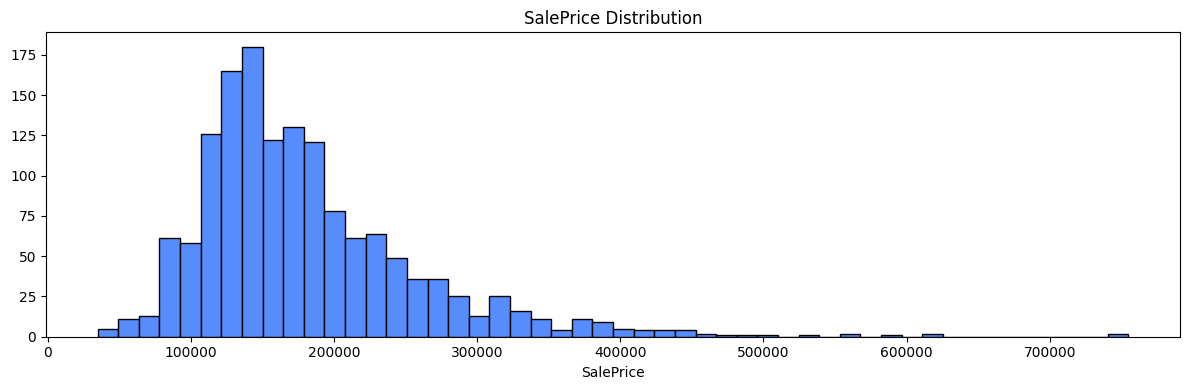

Skewness: 1.883


In [51]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal?

---
## Part 0: Cleanning data

In [52]:
nrow = len(train)
stats_list = []

for col in train.columns:
    n = train[col].isnull().sum()
    ratio_text = f"{n} / {nrow}"
    percentage = (n / nrow) * 100

    stats_list.append({
        'Columns': col,
        'Format (n/nrow)': ratio_text,
        'Missing (%)': round(percentage, 2)
    })

df_stats = pd.DataFrame(stats_list)

print("Columns composition:")
print(df_stats.sort_values(by='Missing (%)', ascending=False).to_string(index=False))

for col in train.columns:
        train[col] = train[col].fillna("None")

# --- VÉRIFICATION APRÈS ---
print("\n--- Results after modifications ---")
total_nans_remaining = train.isnull().sum().sum()
print(f"Amount of empty cells after modifications : {total_nans_remaining}")

Columns composition:
      Columns Format (n/nrow)  Missing (%)
       PoolQC     1453 / 1460        99.52
  MiscFeature     1406 / 1460        96.30
        Alley     1369 / 1460        93.77
        Fence     1179 / 1460        80.75
   MasVnrType      872 / 1460        59.73
  FireplaceQu      690 / 1460        47.26
  LotFrontage      259 / 1460        17.74
  GarageYrBlt       81 / 1460         5.55
   GarageCond       81 / 1460         5.55
   GarageType       81 / 1460         5.55
 GarageFinish       81 / 1460         5.55
   GarageQual       81 / 1460         5.55
 BsmtFinType2       38 / 1460         2.60
 BsmtExposure       38 / 1460         2.60
     BsmtQual       37 / 1460         2.53
     BsmtCond       37 / 1460         2.53
 BsmtFinType1       37 / 1460         2.53
   MasVnrArea        8 / 1460         0.55
   Electrical        1 / 1460         0.07
           Id        0 / 1460         0.00
   Functional        0 / 1460         0.00
   Fireplaces        0 / 1460    

- The following columns have a lot of missing values : PoolQC, MiscFeature, Alley, Fence and FireplaceQu.
- Since we lack data on those columns, they might be less significant but this will have to be proved. For now, we change the missing values to "None" for all the columns (categorical and numerical). We apply "None" to numerical variables as well acknowledging that using 0 for numerical columns can be inappropriate in some cases (For example in LotArea which can not logically have a base value of zero). 

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? 
- Visualize distributions and support your conclusions with plots

In [53]:
#Descriptive statistics for the target variable
sp_mean = train['SalePrice'].mean()
sp_var = train['SalePrice'].var()
print(f'Mean: {sp_mean:,.2f} $, Variance: {sp_var:.3e}')
#add the skewness and kurtosis
print(f'Skewness: {train["SalePrice"].skew():.3f}')
print(f'Kurtosis: {train["SalePrice"].kurtosis():.3f}')

Mean: 180,921.20 $, Variance: 6.311e+09
Skewness: 1.883
Kurtosis: 6.536


In [54]:
# Transforming prices into logs to have a normal distribution. Adding them to the train dataframe
train["SalePrice_log"] = np.log(train['SalePrice'])
sales_price = train['SalePrice_log']

# mean, variance, SD
mean_sales_price = np.mean(sales_price)
n = len(sales_price)
var_sales_price = sum((x - mean_sales_price)**2 for x in sales_price)/(n-1)
std_sales_price = np.sqrt(var_sales_price)

print(sales_price.describe())

print(f'Skewness: {sales_price.skew():.3f}')
print(f'Kurtosis: {sales_price.kurtosis():.3f}')


count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice_log, dtype: float64
Skewness: 0.121
Kurtosis: 0.810


- We went from a skewness of 1.88 for the raw SalePrice to a skewness of 0.12 for the logarithmic SalePrice (reference value in a Normal distribution: 0)
- Kurtosis passed from 6.54 to 0.8 (reference value in a Normal distribution: 3)
- This indicates that the log transformation has significantly improved the normality of the SalePrice variable, making it more suitable for modeling techniques that assume normality.

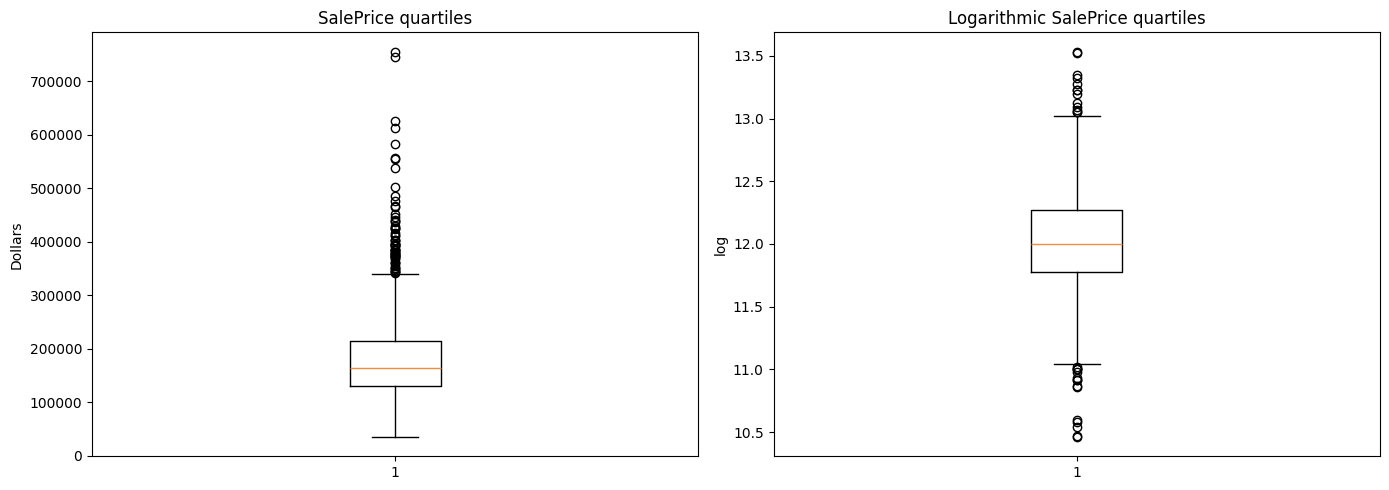

In [55]:
# Comparison of SalePrice and its logarithmic transformation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].boxplot(train["SalePrice"])
ax[0].set_title('SalePrice quartiles')
ax[0].set_ylabel('Dollars')

ax[1].boxplot(train["SalePrice_log"])
ax[1].set_title('Logarithmic SalePrice quartiles')
ax[1].set_ylabel('log')

plt.tight_layout()
plt.show()

In [56]:
print(f"log mean to exp: {np.exp(mean_sales_price)} $")

log mean to exp: 166716.64288689764 $


In [57]:
print("Shapiro test on the whole sample:")
print(stats.shapiro(sales_price))

print("Shapiro test on a random sample of 50 observations:")

print(stats.shapiro(sales_price.sample(50, random_state=30)))
print(stats.shapiro(sales_price.sample(50, random_state=19)))
print(stats.shapiro(sales_price.sample(50, random_state=18)))

print("Shapiro test on a random sample of 100 observations:")
print(stats.shapiro(sales_price.sample(100, random_state=20)))
print(stats.shapiro(sales_price.sample(100, random_state=29)))

Shapiro test on the whole sample:
ShapiroResult(statistic=np.float64(0.9912067503807808), pvalue=np.float64(1.1490615527258487e-07))
Shapiro test on a random sample of 50 observations:
ShapiroResult(statistic=np.float64(0.9345439931614673), pvalue=np.float64(0.008244214194373796))
ShapiroResult(statistic=np.float64(0.9787682077319388), pvalue=np.float64(0.5012617701748905))
ShapiroResult(statistic=np.float64(0.9830310725066443), pvalue=np.float64(0.6847840902885282))
Shapiro test on a random sample of 100 observations:
ShapiroResult(statistic=np.float64(0.9842932594106127), pvalue=np.float64(0.2821132563982034))
ShapiroResult(statistic=np.float64(0.9694529945683682), pvalue=np.float64(0.020075853205616723))


At first we ran a Shapiro test on the entire sample, which retuned a negative result (p-value < 0.05) suggesting the logarithmic transformation didn't normalize the data. Knowing that Shapiro's test isn't suitable for large samples, we ran it again on small randomized samples and we obtained mixed results.
Overall it doesn't look reliable to conclude anything about the normality of the distribution, so we opted for a QQ-plot and an histogram to back up the effectivenss of the normalization.

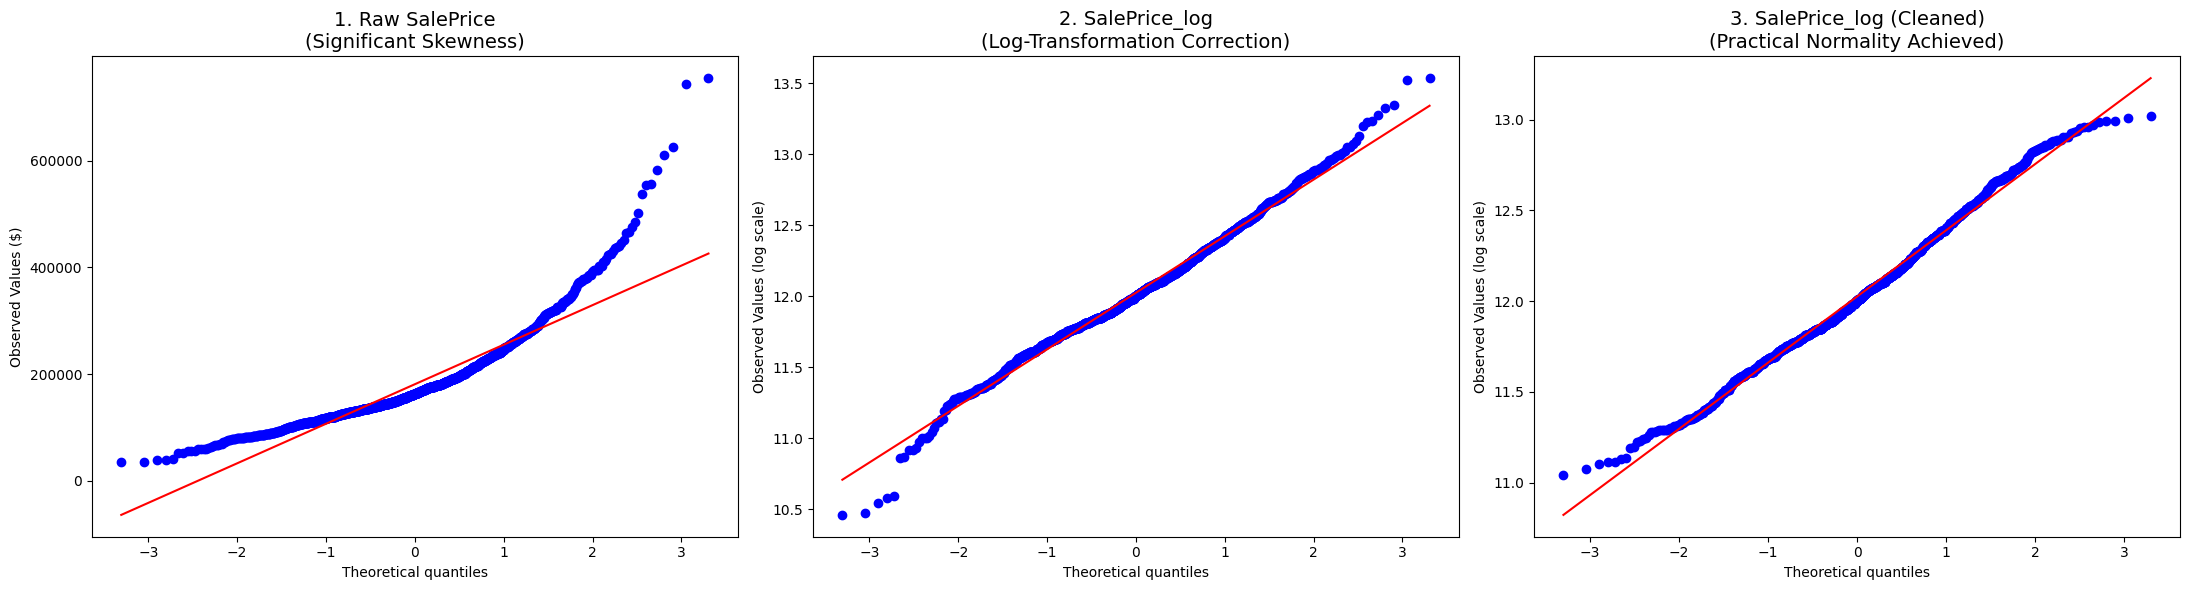

In [58]:
# Prepare the three versions of the target variable
y_raw = train['SalePrice']

# Calculate and remove outliers on the Log version (IQR Method)
Q1 = sales_price.quantile(0.25)
Q3 = sales_price.quantile(0.75)
IQR = Q3 - Q1
# Filtering: keeping only data within 1.5 * IQR
y_log_no_outliers = sales_price[~((sales_price < (Q1 - 1.5 * IQR)) | (sales_price > (Q3 + 1.5 * IQR)))]

# 2. Create the figure (1 row, 3 columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot 1: Raw Data ---
stats.probplot(y_raw, dist="norm", plot=ax1)
ax1.set_title("1. Raw SalePrice\n(Significant Skewness)", fontsize=14)
ax1.set_ylabel("Observed Values ($)")

# --- Plot 2: Log Transformed ---
stats.probplot(sales_price, dist="norm", plot=ax2)
ax2.set_title("2. SalePrice_log\n(Log-Transformation Correction)", fontsize=14)
ax2.set_ylabel("Observed Values (log scale)")

# --- Plot 3: Log + No Outliers ---
stats.probplot(y_log_no_outliers, dist="norm", plot=ax3)
ax3.set_title("3. SalePrice_log (Cleaned)\n(Practical Normality Achieved)", fontsize=14)
ax3.set_ylabel("Observed Values (log scale)")

plt.tight_layout()
plt.show()

Comment :
- We can see that after the logarithmic transformation, data get closer to the quantile of a normal distribution proving that the transformation achieved the aforementioned goal of normalising the data.
- We can also see that the difference between the logarithmic SalePrice with and without outliers is small so we will keep the outliers until further evidence will prove them to be polluting for the overall results.

In [59]:
# Confidence interval for the mean of log price
alpha = 0.05
df = n - 1
t_crit = stats.t.ppf(1-alpha/2, df)
margin_error = t_crit * (std_sales_price/np.sqrt(n))
lower_limit = mean_sales_price - margin_error
upper_limit = mean_sales_price + margin_error
p = stats.t.cdf(t_crit, df)
print(f"Mean's confidence interval at 95% CI: [{lower_limit}, {upper_limit}]")

# CI for variance
a = stats.chi2.ppf(alpha/2, df)
b = stats.chi2.ppf(1-alpha/2, df)

# ((n-1)*sample_var)/b < pop_var < ((n-1)*sample_var)/a
var_lower_limit = (df*var_sales_price)/b
var_upper_limit = (df*var_sales_price)/a

print(f"Confidence Interval (95%) for the variance: [{var_lower_limit}, {var_upper_limit}]")


Mean's confidence interval at 95% CI: [12.003544164729277, 12.04455763748949]
Confidence Interval (95%) for the variance: [0.14858771791596836, 0.17180448306911694]


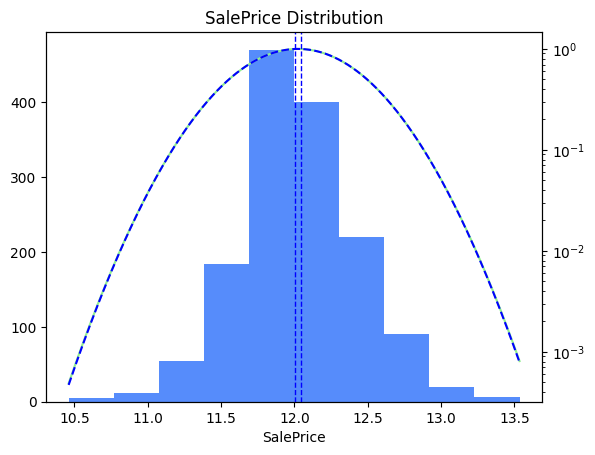

In [60]:
# PLOT
fig, ax = plt.subplots()
plt.hist(sales_price)
x = np.linspace(np.min(sales_price), np.max(sales_price), 1000)

t_dist = stats.t(df, loc=mean_sales_price, scale=std_sales_price)
t_but_normal = stats.norm(mean_sales_price, std_sales_price)

ax2 = ax.twinx()
ax.grid(False)
ax2.plot(x, t_dist.pdf(x), color='lightgreen', label="T Distribution")
ax2.plot(x, t_but_normal.pdf(x), color='blue', linestyle="--", label="Normal")
ax2.set_yscale('log')
ax.set_title('SalePrice Distribution')
ax.set_xlabel('SalePrice')
plt.axvline(lower_limit, color='blue', linestyle='--', linewidth=1)
plt.axvline(upper_limit, color='blue', linestyle='--', linewidth=1)
plt.show()

- The histogram, with the overlay of the Normal curve, shows that the data now follow a Normal distribution.
- The vertical blue lines mark the confidence interval of the mean.
- In the image, a Normal distribution and a T-Student distribution of `SalePrice_log` are overlapped to show that, with the size of this sample, the T-Distribution perfectly follows a Normal curve.


- **Hypothesis testing** — is the mean SalePrice significantly different from \$180,000?
- H0 : mean = \$180,000
- H1 : mean != \$180,000

In [61]:
# Transforming 180000 into log to make it comparable with SalePrice_log
h0_mean = np.log(180000)
print(f"H0 mean: {h0_mean}")

t_h0, p_h0 = stats.ttest_1samp(sales_price, h0_mean, alternative='two-sided')


if p_h0 < alpha:
    print(f"p-val < alpha: {p_h0 < alpha}")
    print("So we reject the null hypothesis")
else:
    print("Oh no, The null hypothesis was right!")

H0 mean: 12.100712129872347
p-val < alpha: True
So we reject the null hypothesis


#### Analysis of the numerical features

We can identify some key features as the ones that are the most correlated with `SalePrice_log`. A correlation coefficient bigger than 0.6 or smaller than -0.6 suggest a strong association with the compared variable.

In [62]:
correlations = train.corr(numeric_only=True)['SalePrice_log'].sort_values(ascending=False)


key_features = []
for feature in correlations.index:
    print(f'- {feature} : {correlations[feature]:.3f}')
    if correlations[feature] >= 0.6 and feature not in ["SalePrice", "SalePrice_log"]:
        key_features.append(feature)


- SalePrice_log : 1.000
- SalePrice : 0.948
- OverallQual : 0.817
- GrLivArea : 0.701
- GarageCars : 0.681
- GarageArea : 0.651
- TotalBsmtSF : 0.612
- 1stFlrSF : 0.597
- FullBath : 0.595
- YearBuilt : 0.587
- YearRemodAdd : 0.566
- TotRmsAbvGrd : 0.534
- Fireplaces : 0.489
- BsmtFinSF1 : 0.372
- WoodDeckSF : 0.334
- OpenPorchSF : 0.321
- 2ndFlrSF : 0.319
- HalfBath : 0.314
- LotArea : 0.257
- BsmtFullBath : 0.236
- BsmtUnfSF : 0.222
- BedroomAbvGr : 0.209
- ScreenPorch : 0.121
- PoolArea : 0.070
- MoSold : 0.057
- 3SsnPorch : 0.055
- BsmtFinSF2 : 0.005
- BsmtHalfBath : -0.005
- Id : -0.018
- MiscVal : -0.020
- OverallCond : -0.037
- YrSold : -0.037
- LowQualFinSF : -0.038
- MSSubClass : -0.074
- KitchenAbvGr : -0.148
- EnclosedPorch : -0.149


In [63]:
print('Features with a correlation >= 0.6:')

for feature in key_features:
    print(f'- {feature} : {correlations[feature]:.3f}')

Features with a correlation >= 0.6:
- OverallQual : 0.817
- GrLivArea : 0.701
- GarageCars : 0.681
- GarageArea : 0.651
- TotalBsmtSF : 0.612


Commentary on the correlation results:
- The most positively correlated features with SalePrice are `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea` and `TotalBsmtSF`. This makes sense since **these features are related to the quality** and **size of the house**, which are important factors in determining its price.
- There are **no features that are strongly negatively** correlated with SalePrice, which suggests that there are no features in the database which will strongly negatively affect the SalePrince.


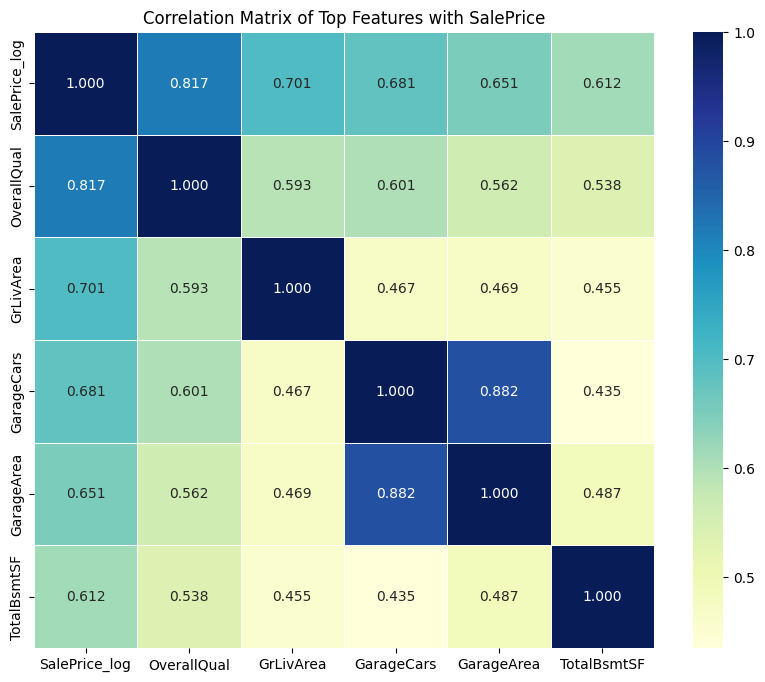

In [64]:
# Correlation

top_corr = train[["SalePrice_log"]+key_features].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=0.5)

plt.title("Correlation Matrix of Top Features with SalePrice")
plt.show()

Commentary on the correlation matrix:
- `GarageCars` and `GarageArea` are highly correlated with each other (0.88), which makes sense since they both measure the size of the garage. If a garage is big, it can contains more cars. So we could consider keeping only one of them in our model to avoid multicollinearity issues.


In [65]:
#general descriptive statistics for the key features
stats_summary = train[key_features].agg(['mean', 'var', 'std']).T

stats_summary.columns = ['Mean', 'Variance', 'Standard Deviation']
print(stats_summary)

                    Mean       Variance  Standard Deviation
OverallQual     6.099315       1.912679            1.382997
GrLivArea    1515.463699  276129.633363          525.480383
GarageCars      1.767123       0.558480            0.747315
GarageArea    472.980137   45712.510229          213.804841
TotalBsmtSF  1057.429452  192462.361709          438.705324


Commentary

- `OverallQual`: The mean of 6.1/10 indicates that the overall material and finishing of the house is generally ‘Above average’ with a relatively low degree of variation (standard deviation = 1.38).
- `GrLivArea`: The average living area is 1'515 square feet, but the high standard deviation of 525 indicates a wide range of sizes.
- `GarageCars`: With an average of 1.77 and a standard deviation 0.75, suggests that a garage can contain between 1 and 3.
- `GarageArea`: The average garage area is 473 square feet. The variance of 213 confirms the variation of "GarageCars".
- `TotalBsmtSF`: The basement averages 1'057 square feet with a standard deviation of 438, suggesting that also this variable can vary quite a lot.

#### Analysis of `ExterQuality` (categorical)

Analyzing the variation of prices based on the External Quality with a quick comparison and a plot, we can easily hypothesize that the external quality has some influence on the price. So we proceed with a few hypothesis tests to better explore this relationship.

,mean,min,max,std,count
ExterQual,,,,,
Ex,12.764044,11.982929,13.534473,0.325699,52
Fa,11.304541,10.578980,12.206073,0.406416,14
Gd,12.311282,10.858999,13.521139,0.285985,488
TA,11.837985,10.460242,12.850555,0.293697,906


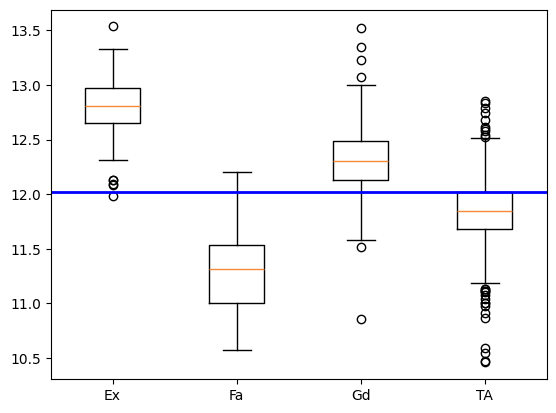

In [66]:
data_to_plot = [group["SalePrice_log"] for name, group in train.groupby("ExterQual")]
labels = [name for name, group in train.groupby("ExterQual")]

plt.boxplot(data_to_plot, tick_labels=labels)
plt.axhline(mean_sales_price, color='blue', linewidth=2)


plt.grid(False)
train["SalePrice_log"].groupby(train["ExterQual"]).agg(["mean", "min", "max", "std", "count"])

- Blue line: Overall average price (log)

- **Hypothesis testing** — the mean of `SalePrice_log` doesn't have significant variations between the `ExterQual` = `Ex` (Excellent) and the other levels of ExterQual (Gd, TA or Fa).

We have to run multiple tests.
1. We compare `Ex` with `Gd` (Good)
- H0 : mean_Ex - mean_Gd = 0
- H1 : mean_Ex - mean_Gd != 0

In [67]:
Ex = train.loc[train["ExterQual"] == "Ex", "SalePrice_log"]
Gd = train.loc[train["ExterQual"] == "Gd", "SalePrice_log"]

mean_Ex = Ex.mean()
mean_Gd = Gd.mean()
diff_means = mean_Ex - mean_Gd

n_Ex = len(Ex)
n_Gd = len(Gd)
df_ExGd = n_Ex + n_Gd - 2

var_Ex = sum((x - mean_Ex)**2 for x in Ex)/(n_Ex-1)
var_Gd = sum((x - mean_Gd)**2 for x in Gd)/(n_Gd-1)
sample_var_pool = ((n_Ex-1) * var_Ex + (n_Gd-1) * var_Gd)/ df_ExGd

t_diff = diff_means/ np.sqrt(sample_var_pool * (1/n_Ex + 1/n_Gd))
t_crit = stats.t.ppf(1-alpha/2, df_ExGd)
margin_error = t_crit * np.sqrt(sample_var_pool * (1/n_Ex + 1/n_Gd))

lower_limit = diff_means - margin_error
upper_limit = diff_means + margin_error

print(f"Confidence Interval (95%): [{lower_limit},{upper_limit}]. Because 0 is not in the interval, we can reject the null hypothesis")

Confidence Interval (95%): [0.3696651243584748,0.5358585899114827]. Because 0 is not in the interval, we can reject the null hypothesis


2. We compare Ex with TA (Typical/Average)
- H0 : mean_Ex - mean_TA = 0
- H1 : mean_Ex - mean_TA != 0

In [68]:
TA = train.loc[train["ExterQual"] == "TA", "SalePrice_log"]
mean_TA = TA.mean()
diff_means = mean_Ex - mean_TA

n_TA = len(TA)
df_ExTA = n_Ex + n_TA - 2

var_TA = sum((x - mean_TA)**2 for x in TA)/(n_TA-1)
sample_var_pool = ((n_Ex-1) * var_Ex + (n_TA-1) * var_TA)/ df_ExTA

t_diff = diff_means/ np.sqrt(sample_var_pool * (1/n_Ex + 1/n_TA))
t_crit = stats.t.ppf(1-alpha/2, df_ExTA)
margin_error = t_crit * np.sqrt(sample_var_pool * (1/n_Ex + 1/n_TA))

lower_limit = diff_means - margin_error
upper_limit = diff_means + margin_error

print(f"Interval: [{lower_limit},{upper_limit}]. Because 0 is not in the interval, we can reject the null hypothesis")

Interval: [0.8433676535135881,1.008750552914141]. Because 0 is not in the interval, we can reject the null hypothesis


3. We compare Ex with Fa (Fair)
- H0 : mean_Ex - mean_Fa = 0
- H1 : mean_Ex - mean_Fa != 0

In [69]:
Fa = train.loc[train["ExterQual"] == "Fa", "SalePrice_log"]
mean_Fa = Fa.mean()
diff_means = mean_Ex - mean_Fa

n_Fa = len(Fa)
df_ExFa = n_Ex + n_Fa - 2

var_Fa = sum((x - mean_Fa)**2 for x in Fa)/(n_Fa-1)
sample_var_pool = ((n_Ex-1) * var_Ex + (n_Fa-1) * var_Fa)/ df_ExFa

t_diff = diff_means/ np.sqrt(sample_var_pool * (1/n_Ex + 1/n_Fa))
t_crit = stats.t.ppf(1-alpha/2, df_ExFa)
margin_error = t_crit * np.sqrt(sample_var_pool * (1/n_Ex + 1/n_Fa))

lower_limit = diff_means - margin_error
upper_limit = diff_means + margin_error

print(f"Interval: [{lower_limit},{upper_limit}]. Because 0 is not in the interval, we can reject the null hypothesis")

Interval: [1.2528048839347037,1.6662018426459084]. Because 0 is not in the interval, we can reject the null hypothesis


We can successfully conclude that the mean price significantly changes between groups.

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Summarize: which features and interactions are significant?

### One way ANOVA

In [70]:
features = ['OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual','FireplaceQu', 'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold']

df_anova = train[features + ["SalePrice_log"]].copy()

results = []
for col in features:
    groups = [group["SalePrice_log"].values for name, group in df_anova.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups, equal_var=False)
    results.append({
        "Feature": col,
        "F-Statistic": f_stat,
        "p-value": p_val,
        "Significant (<0.05)": p_val < 0.05
    })

anova_r = pd.DataFrame(results).sort_values(by="p-value", ascending=True)
anova_r

,Feature,F-Statistic,p-value,Significant (<0.05)
3,KitchenQual,333.007762,1.449809e-63,True
2,BsmtQual,266.929958,5.362056e-61,True
4,FireplaceQu,123.551997,1.209933e-39,True
1,ExterQual,379.640381,1.910097e-35,True
5,CentralAir,189.743580,2.196567e-25,True
0,OverallQual,239.828135,2.125367e-18,True
6,LotShape,46.110553,1.313347e-12,True
7,LandSlope,0.707069,5.018437e-01,False
8,MoSold,0.926958,5.141174e-01,False
9,YrSold,0.731210,5.708268e-01,False


NOTE: This observation was made on f_oneway with , equal_var=True, so the reults were highly impacted by the heteroscedasticity of the groups. 
//----------------------------------
It's interesting to notice that the OverallQual has a p-value of almost 0 but the F-statistic is not the biggest one in the list. We can explain this by checking the degrees of freedom. This specific variable has df = 9, so obviously the F-statistic is smaller in value if compared to the other variables. So, even though 332 is not the biggest F-statistic on the list, the weight of this variable appears to be the biggest one, given that MSA = SSA/DFA and FA = MSA/MSE.
//---------------------------------


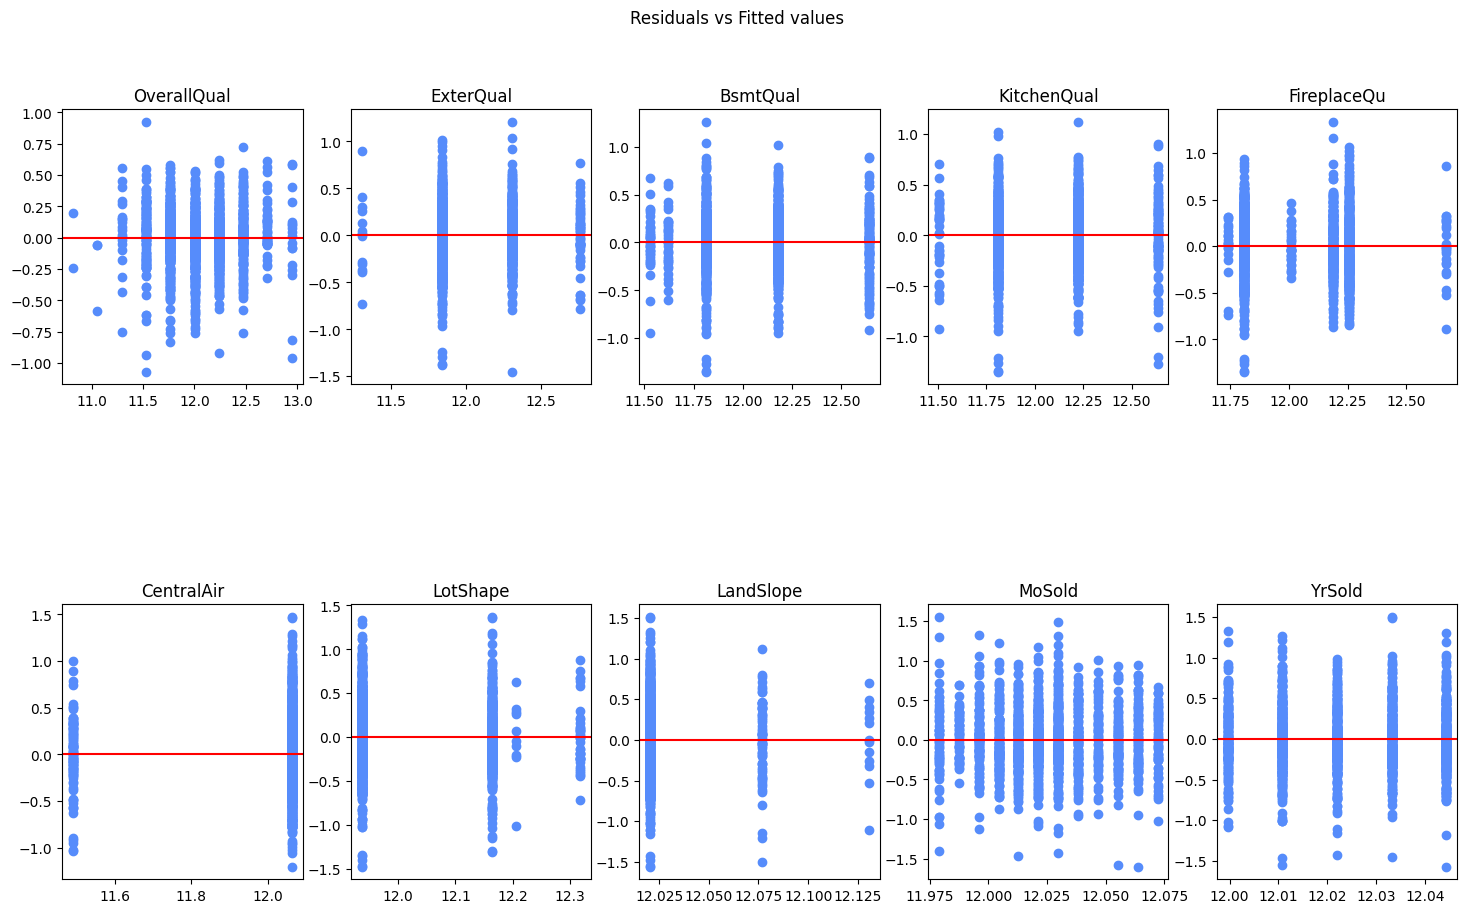

In [71]:

# Residuals and fitted values

fig, axs = plt.subplots(2, int(len(features)/2), figsize=(18, 10))
fig.subplots_adjust(hspace=0.8)
fig.get_axes()
fig.suptitle("Residuals vs Fitted values")
y = 0
x = 0
for feature in features:

    model = ols(f'SalePrice_log ~ {feature}', data=train).fit()

    axs[x, y].scatter(model.fittedvalues, model.resid)
    axs[x, y].axhline(0, color="red")
    axs[x, y].set_title(f"{feature}")
    y += 1
    if y >= int(len(features)/2):
        x += 1
        y = 0


No clear pattern seems to appear in the analysis of the residuals except for LandSlope, where a funnel shape is identifiable, indicating an unequal variance of the residuals. In LandSlope, some groups have much higher variability than others, violating a key requirement for a valid ANOVA test for this variable.

In [72]:
# Out of curiosity we decide to check the results for all the columns
all_features = train.select_dtypes(include=["object", "str"]).columns.tolist()

results = []
for col in all_features:
    groups = [group["SalePrice_log"].values for name, group in train.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    results.append({
        "Feature": col,
        "F-Statistic": f_stat,
        "p-value": p_val,
        "Significant (0.05)": p_val < 0.05
    })

anova_t = pd.DataFrame(results).sort_values(by="p-value", ascending=True)
anova_t.head(10)

,Feature,F-Statistic,p-value,Significant (0.05)
9,Neighborhood,79.520424,4.043304e-243,True
20,ExterQual,415.303357,6.935425e-195,True
23,BsmtQual,300.392324,2.031282e-188,True
32,KitchenQual,393.320196,4.441486e-187,True
37,GarageFinish,298.769753,4.057458e-151,True
35,GarageType,121.796388,8.427845e-125,True
36,GarageYrBlt,11.637505,1.641363e-120,True
34,FireplaceQu,131.198459,6.963458e-115,True
22,Foundation,126.806748,1.350671e-111,True
29,HeatingQC,110.820436,1.614882e-82,True


Text(0.5, 0, 'SalePrice_log')

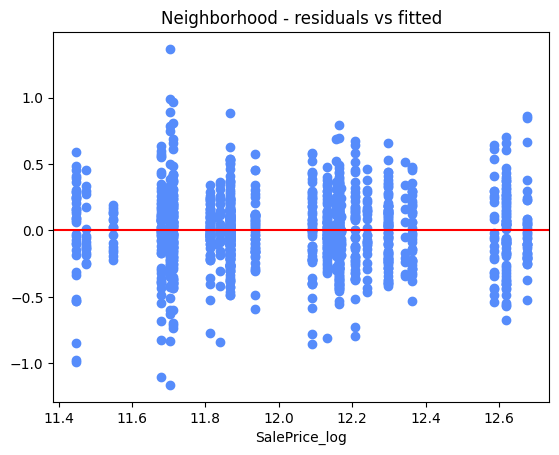

In [73]:
model = ols(f'SalePrice_log ~ Neighborhood', data=train).fit()

plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color="red")
plt.title("Neighborhood - residuals vs fitted")
plt.xlabel("SalePrice_log")


In [74]:
groups = [group["SalePrice_log"].values for name, group in train.groupby("Neighborhood")]
results = []
f_stat, p_val = stats.f_oneway(*groups, equal_var=False)
results.append({
    "Feature": "Neighborhood",
    "F-Statistic": f_stat,
    "p-value": p_val,
    "Significant (0.05)": p_val < 0.05
})

anova_ne = pd.DataFrame(results).sort_values(by="p-value", ascending=True)
anova_ne

,Feature,F-Statistic,p-value,Significant (0.05)
0,Neighborhood,69.046141,6.911727e-59,True


Here follow the results of Tukey's tests for the top 4 features appeared in the global ANOVA test.
- ExterQual seems to be always influencing price
- OverallQual seems to be important in most cases, with the exceptions of grades 1-2 and 9-10
- GarageCars also seems to be important, although there appears to be no relevant difference between a garage with a 2 or 4 cars capacity
- The Neighborhoods have significantly different means in half of the cases. A better knowledge of the geography might help to group them into macro-zones that might explain or not this behavior

In [75]:
tukey = pairwise_tukeyhsd(endog=train['SalePrice_log'],
                          groups=train['ExterQual'],
                          alpha=0.05)

print(tukey.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Ex     Fa  -1.4595   0.0 -1.6868 -1.2322   True
    Ex     Gd  -0.4528   0.0 -0.5629 -0.3426   True
    Ex     TA  -0.9261   0.0 -1.0337 -0.8184   True
    Fa     Gd   1.0067   0.0  0.8021  1.2114   True
    Fa     TA   0.5334   0.0  0.3301  0.7368   True
    Gd     TA  -0.4733   0.0 -0.5157 -0.4309   True
---------------------------------------------------


In [76]:
tukey = pairwise_tukeyhsd(endog=train['SalePrice_log'],
                          groups=train['OverallQual'],
                          alpha=0.05)

print(tukey.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9819    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0  0.6541  1.683   True
     1      7    1.423    0.0  0.9083 1.9377   True
     1      8   1.6984    0.0  1.1823 2.2145   True
     1      9   1.9945    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3075 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2492 2.0945   True
     2      9   1.9679    0.0  1.5346 2.4012   True
     2     1

In [77]:
tukey = pairwise_tukeyhsd(endog=train['SalePrice_log'],
                          groups=train['BsmtQual'],
                          alpha=0.05)

print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    Ex     Fa  -1.0228    0.0  -1.178 -0.8676   True
    Ex     Gd  -0.4605    0.0 -0.5409 -0.3801   True
    Ex   None  -1.1107    0.0 -1.2626 -0.9588   True
    Ex     TA  -0.8295    0.0 -0.9096 -0.7495   True
    Fa     Gd   0.5623    0.0  0.4218  0.7028   True
    Fa   None  -0.0879 0.7161 -0.2786  0.1027  False
    Fa     TA   0.1933 0.0016   0.053  0.3336   True
    Gd   None  -0.6502    0.0  -0.787 -0.5134   True
    Gd     TA   -0.369    0.0 -0.4145 -0.3236   True
  None     TA   0.2812    0.0  0.1445  0.4178   True
----------------------------------------------------


In [78]:
tukey = pairwise_tukeyhsd(endog=train['SalePrice_log'],
                          groups=train['KitchenQual'],
                          alpha=0.05)

print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    Ex     Fa   -1.129   0.0 -1.2733 -0.9847   True
    Ex     Gd  -0.4113   0.0  -0.494 -0.3286   True
    Ex     TA   -0.823   0.0 -0.9045 -0.7416   True
    Fa     Gd   0.7178   0.0  0.5914  0.8442   True
    Fa     TA    0.306   0.0  0.1804  0.4316   True
    Gd     TA  -0.4117   0.0 -0.4541 -0.3694   True
---------------------------------------------------


In [79]:
tukey = pairwise_tukeyhsd(endog=train['SalePrice_log'],
                          groups=train['Neighborhood'],
                          alpha=0.05)
res = tukey.summary()
df_tukey_ne = pd.DataFrame(res.data[1:], columns=res.data[0])
df_tukey_ne


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Blmngtn,Blueste,-0.3429,0.9914,-1.0659,0.3801,False
1,Blmngtn,BrDale,-0.6216,0.0000,-0.9584,-0.2847,True
2,Blmngtn,BrkSide,-0.4897,0.0000,-0.7564,-0.2230,True
3,Blmngtn,ClearCr,0.0705,1.0000,-0.2269,0.3678,False
4,Blmngtn,CollgCr,-0.0058,1.0000,-0.2533,0.2417,False
...,...,...,...,...,...,...,...
295,Somerst,Timber,0.0670,0.9999,-0.1214,0.2553,False
296,Somerst,Veenker,0.0477,1.0000,-0.2620,0.3574,False
297,StoneBr,Timber,-0.2220,0.1640,-0.4711,0.0270,False
298,StoneBr,Veenker,-0.2413,0.6748,-0.5912,0.1086,False


### Two-way ANOVA


In [80]:
combinations = ["SalePrice_log~C(OverallQual)*ExterQual", "SalePrice_log~C(OverallQual)*BsmtQual", "SalePrice_log~C(OverallQual)*KitchenQual", "SalePrice_log~C(OverallQual)*FireplaceQu", "SalePrice_log~C(OverallQual)*CentralAir", "SalePrice_log~C(OverallQual)*LotShape", "SalePrice_log~ExterQual*BsmtQual", "SalePrice_log~ExterQual*KitchenQual", "SalePrice_log~ExterQual*FireplaceQu", "SalePrice_log~ExterQual*CentralAir", "SalePrice_log~ExterQual*LotShape", "SalePrice_log~BsmtQual*KitchenQual", "SalePrice_log~BsmtQual*FireplaceQu", "SalePrice_log~BsmtQual*CentralAir", "SalePrice_log~BsmtQual*LotShape", "SalePrice_log~KitchenQual*FireplaceQu", "SalePrice_log~KitchenQual*CentralAir", "SalePrice_log~KitchenQual*LotShape", "SalePrice_log~FireplaceQu*CentralAir", "SalePrice_log~FireplaceQu*LotShape", "SalePrice_log~CentralAir*LotShape", "SalePrice_log~ExterQual*Neighborhood", "SalePrice_log~C(OverallQual)*Neighborhood", "SalePrice_log~CentralAir*Neighborhood"]

In [81]:
results_list = []
warnings.filterwarnings('ignore', category=sm.stats.stattools.ValueWarning)

for f in combinations:
    try:
        model = ols(f, data=train).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        p_val_interaction = anova_table.iloc[2]['PR(>F)']

        results_list.append({
            'formula': f,
            'p_value_interaction': p_val_interaction,
            'rsquared_adj': model.rsquared_adj
        })

    except Exception as e:
        print(f"Exception: {e}")
        continue

anova_results = pd.DataFrame(results_list)

significant_results = anova_results[anova_results['p_value_interaction'] < 0.05].sort_values(by='p_value_interaction')

print("\n--- Most relevant interactions ---")
significant_results




--- Most relevant interactions ---


,formula,p_value_interaction,rsquared_adj
0,SalePrice_log~C(OverallQual)*ExterQual,0.000000e+00,0.689606
21,SalePrice_log~ExterQual*Neighborhood,0.000000e+00,0.649520
18,SalePrice_log~FireplaceQu*CentralAir,0.000000e+00,0.372475
13,SalePrice_log~BsmtQual*CentralAir,0.000000e+00,0.492304
22,SalePrice_log~C(OverallQual)*Neighborhood,0.000000e+00,0.773513
9,SalePrice_log~ExterQual*CentralAir,0.000000e+00,0.506340
23,SalePrice_log~CentralAir*Neighborhood,0.000000e+00,0.595155
3,SalePrice_log~C(OverallQual)*FireplaceQu,0.000000e+00,0.707665
2,SalePrice_log~C(OverallQual)*KitchenQual,8.524933e-242,0.693845
1,SalePrice_log~C(OverallQual)*BsmtQual,7.013629e-222,0.695224


In conclusion, some significant features based on the one-way ANOVA results are:
- OverallQual, ExterQual, BsmtQual, KitchenQual, FireplaceQu, CentralAir, LotShape.

On a closer look, only 9 features appear to be not significant.

The significant interactions emerged with a 2-way ANOVA test are:
- OverallQual - ExterQual
- OverallQual - FireplaceQu
- BsmtQual - CentralAir
- ExterQual - CentralAir
- FireplaceQu - CentralAir
- OverallQual - KitchenQual
- OverallQual - BsmtQual
- KitchenQua - FireplaceQu
- BsmtQual - KitchenQual
- ExterQual - BsmtQual

After some reasoning, we decided to keep checking the influence of the Neighborhood combined with some features and obtained very small p-values and quite high R^2 for the explored interactions.

In [82]:
results_list = []
warnings.filterwarnings('ignore', category=sm.stats.stattools.ValueWarning)

for f in combinations:
    try:
        model = ols(f, data=train).fit()
        anova_table = sm.stats.anova_lm(model, typ=3, robust="hc3")

        p_val_interaction = anova_table.iloc[2]['PR(>F)']

        results_list.append({
            'formula': f,
            'p_value_interaction': p_val_interaction,
            'rsquared_adj': model.rsquared_adj
        })

    except Exception as e:
        print(f"Exception: {e}")
        continue

anova_results = pd.DataFrame(results_list)

significant_results = anova_results[anova_results['p_value_interaction'] < 0.05].sort_values(by='p_value_interaction')

print("\n--- Most relevant interactions ---")
significant_results



Exception: r_matrix performs f_test for using dimensions that are asymptotically non-normal
Exception: r_matrix performs f_test for using dimensions that are asymptotically non-normal

--- Most relevant interactions ---


/Users/joaorocha/Documents/Uni/Data science/Semestre 4/Computational statistics/cstat/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
/Users/joaorocha/Documents/Uni/Data science/Semestre 4/Computational statistics/cstat/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
/Users/joaorocha/Documents/Uni/Data science/Semestre 4/Computational statistics/cstat/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1971: RuntimeWarning: invalid value encountered in multiply
  scale[:, None] * self.model.pinv_wexog.T)


,formula,p_value_interaction,rsquared_adj
21,SalePrice_log~CentralAir*Neighborhood,0.000000e+00,0.595155
12,SalePrice_log~BsmtQual*CentralAir,2.563100e-264,0.492304
8,SalePrice_log~ExterQual*CentralAir,4.535604e-135,0.506340
20,SalePrice_log~ExterQual*Neighborhood,4.302560e-112,0.649520
16,SalePrice_log~KitchenQual*LotShape,3.959383e-59,0.487006
6,SalePrice_log~ExterQual*KitchenQual,1.630982e-37,0.533637
10,SalePrice_log~BsmtQual*KitchenQual,5.044367e-34,0.572838
7,SalePrice_log~ExterQual*FireplaceQu,1.805272e-09,0.574881
14,SalePrice_log~KitchenQual*FireplaceQu,1.077033e-07,0.569573
11,SalePrice_log~BsmtQual*FireplaceQu,2.222996e-07,0.571103


As it emerged that typ=3 and robust="hc3" provide more robust results for the type of data we're dealing with, we've also tried these parameters. It's our understanding that most of the interactions we've found with typ=2 still hold, but OverallQual is probably too scattered for this type of analysis.

The other interactions seem to hold well this second test.

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [83]:
print(len(train[train.CentralAir != 'Y']))

95


In [84]:
df_doe = train.copy()

# Here I binarize the results with 1 and (-1). Taking example on the lab6.
# Factor A : OverallQual (High if > 6)
df_doe['Factor_A'] = np.where(df_doe['OverallQual'] > 6, 1, -1) # Here the .where allows us to attribute the value of 1 when the mark is >6 and -1 if otherwhise.
# Factor B : ExterQual (Ex ou Gd = High level, Otherwhise = Low level)
df_doe['Factor_B'] = np.where(df_doe['ExterQual'].isin(['Ex', 'Gd']), 1, -1)

# Factor C : CentralAir (Yes = 1, No = (-1) )
df_doe['Factor_C'] = np.where(df_doe['CentralAir'] == 'Y', 1, -1)


# We want r observation for each one of the 2^3 = 8 observations
r = 15 # Saw a video that said that from 15 observations, the distribution follows a normal distribution.
balanced_samples = []
levels = [-1, 1]

for a in levels:  # Triple loop for de 2^3
    for b in levels:
        for c in levels:
            # Filtrering
            subset = df_doe[
                (df_doe['Factor_A'] == a) &
                (df_doe['Factor_B'] == b) &
                (df_doe['Factor_C'] == c)
            ]

            # Verification : if the subset is empty, the sample won't work.
            if len(subset) < r:
                print(f"Overall Quality :{a}, External Quality: {b}, Air Conditioning :{c} has les than 15 datapoints : {len(subset)} points")
                # We use replace = True in case we don't have enough data. It oversamples so the code doesn't crash.
                sampled = subset.sample(n=r, random_state=42, replace=True)
                #The random_state "fixes" the results to avoid a random sample each time, the value 42 is an inside joke that I find funny xD.
            else:
                sampled = subset.sample(n=r, random_state=42)

            balanced_samples.append(sampled)

# Concaténation
df_balanced = pd.concat(balanced_samples)
print(f"Balanced data set : {len(df_balanced)} observations.")


# Regression model and AI

# The formula A*B*C generates : A, B, C, AB, AC, BC and ABC
formula = 'SalePrice_log ~ Factor_A * Factor_B * Factor_C'
model = ols(formula, data=df_balanced).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n--- ANOVA table for 2^3 Factorial Design ---")
print(anova_table)

# Filtre to only keep the statistically significant effects
significant_effects = anova_table[anova_table['PR(>F)'] < 0.05]
print("\nSignificant Effects (p-value < 0.05) :")
print(significant_effects)

print(f"\nR^2 = {model.rsquared:.2f}")
print(f"R^2_adj = {model.rsquared_adj:.2f}")

print("\n Regression model (Weights / Coefficients)")
print(model.params)

Overall Quality :-1, External Quality: 1, Air Conditioning :-1 has les than 15 datapoints : 2 points
Overall Quality :1, External Quality: -1, Air Conditioning :-1 has les than 15 datapoints : 4 points
Overall Quality :1, External Quality: 1, Air Conditioning :-1 has les than 15 datapoints : 2 points
Balanced data set : 120 observations.

--- ANOVA table for 2^3 Factorial Design ---
                              sum_sq     df           F        PR(>F)
Factor_A                    5.764318    1.0  116.266219  5.043547e-19
Factor_B                    1.871986    1.0   37.757932  1.256824e-08
Factor_A:Factor_B           0.231255    1.0    4.664412  3.292619e-02
Factor_C                    2.801406    1.0   56.504325  1.487179e-11
Factor_A:Factor_C           0.082635    1.0    1.666750  1.993528e-01
Factor_B:Factor_C           0.110595    1.0    2.230699  1.381045e-01
Factor_A:Factor_B:Factor_C  0.369901    1.0    7.460895  7.327408e-03
Residual                    5.552804  112.0         Na

We used a resampling to treat the cases where our subsets are smaller than 15. In our case, we got 3 subsets out of 8 that had to be resampled. We printed them out so we can know exactly which combinaison has less than 15 datapoints. This implies that those specific substets have duplicates.

In [37]:
model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Results: Ordinary least squares
===========================================================================
Model:                  OLS                 Adj. R-squared:        0.649   
Dependent Variable:     SalePrice_log       AIC:                   -12.2374
Date:                   2026-05-26 15:43    BIC:                   10.0625 
No. Observations:       120                 Log-Likelihood:        14.119  
Df Model:               7                   F-statistic:           32.36   
Df Residuals:           112                 Prob (F-statistic):    3.57e-24
R-squared:              0.669               Scale:                 0.049579
---------------------------------------------------------------------------
                            Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
---------------------------------------------------------------------------
Intercept                  11.9529   0.0203 588.0538 0.0000 11.9126 11.9932
Factor_A                    0.2192   0.0203  10.7827 0.0000  0.1789  0.2594
Factor_B                    0.1249   0.0203   6.1447 0.0000  0.0846  0.1652
Factor_A:Factor_B           0.0439   0.0203   2.1597 0.0329  0.0036  0.0842
Factor_C                    0.1528   0.0203   7.5169 0.0000  0.1125  0.1931
Factor_A:Factor_C          -0.0262   0.0203  -1.2910 0.1994 -0.0665  0.0140
Factor_B:Factor_C          -0.0304   0.0203  -1.4936 0.1381 -0.0706  0.0099
Factor_A:Factor_B:Factor_C -0.0555   0.0203  -2.7315 0.0073 -0.0958 -0.0152
---------------------------------------------------------------------------
Omnibus:                  33.573          Durbin-Watson:             2.135 
Prob(Omnibus):            0.000           Jarque-Bera (JB):          86.532
Skew:                     1.044           Prob(JB):                  0.000 
Kurtosis:                 6.598           Condition No.:             1     
===========================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is
correctly specified.
"""

R^2_adj = 0.65 suggests that these 3 variables are responsable of 65% of the price variation.
We can see that the elements that have a small p-value and then reject ANOVA are A, B, C, AB and ABC. The main effects A,B,C have a strong impact, while the interaction AB and the interaction ABC have a minor impact.

The interaction AC and BC have p-values > 0.05, so they're not significant.

It's interesting to point out that the weight of ABC is very small and negative. We think that the negative coefficient ABC balances AB, so that we don't overestimate the combinaison of the three factors
way that doesn't affect the price that much compared to the main effects.
For example,

 by the (with good quality and exterior) doesn't have an important price increase by having air conditioning. We only had 3 subsets that needed resampling and those all have in common the value of CentralAir = -1. We can explain this by looking at the number of houses where central air is not present. We can than see that only 95 houses out of 1460 don't have central air.




Balances data set : 120 observations.


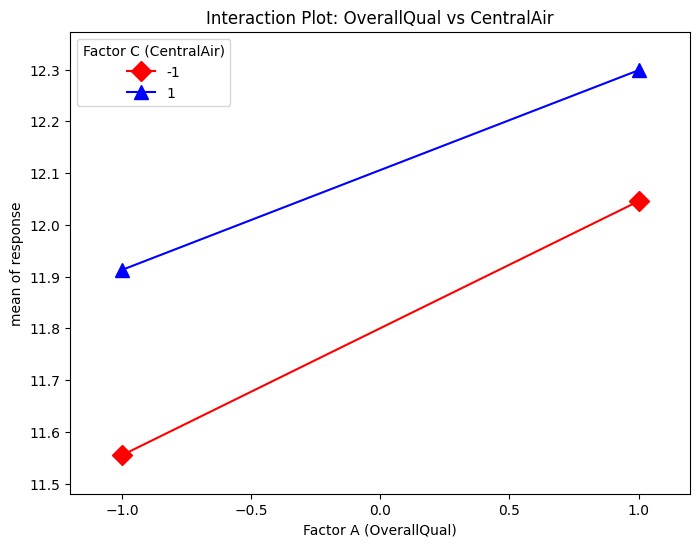

Balances data set : 120 observations.


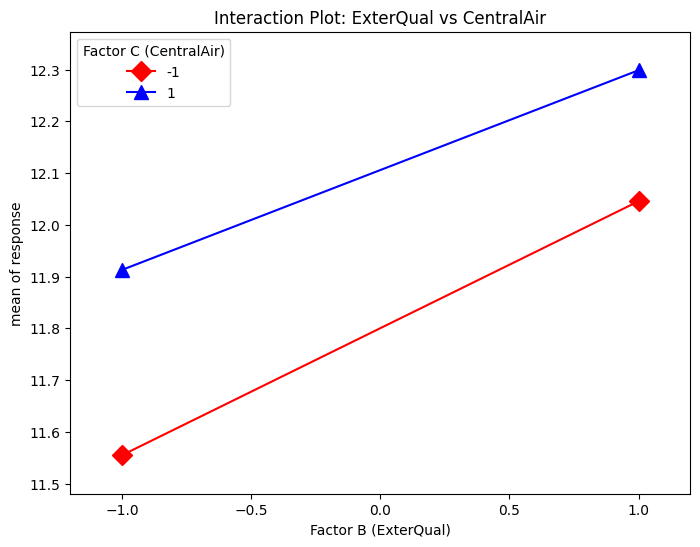

Balances data set : 120 observations.


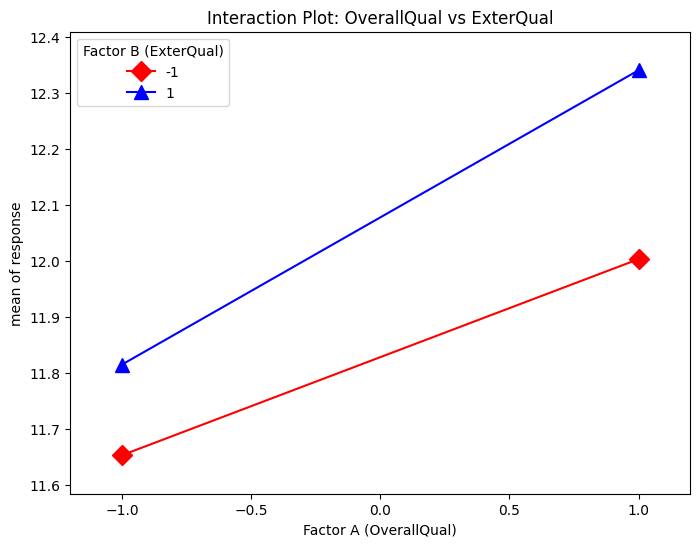

In [38]:
#1.Recreate the balanced DataFrame by reinitializing the index
# df_balanced = pd.concat(balanced_samples).reset_index(drop=True)

print(f"Balances data set : {len(df_balanced)} observations.")

# 2. Redo the model (makes the data match)
fig, ax = plt.subplots(figsize=(8, 6))
# We use .values to avoid the indexation problems with pandas (seen with AI).
interaction_plot(x=df_balanced['Factor_A'].values,
                 trace=df_balanced['Factor_C'].values,
                 response=df_balanced["SalePrice_log"].values,
                 colors=['red', 'blue'],
                 markers=['D', '^'],
                 ms=10, ax=ax)

plt.title("Interaction Plot: OverallQual vs CentralAir")
plt.xlabel("Factor A (OverallQual)")
plt.legend(title="Factor C (CentralAir)")
plt.show()

#Doing a second one with interaction between Factor B and C

print(f"Balances data set : {len(df_balanced)} observations.")

fig, ax = plt.subplots(figsize=(8, 6))
interaction_plot(x=df_balanced['Factor_A'].values,
                 trace=df_balanced['Factor_C'].values,
                 response=df_balanced["SalePrice_log"].values,
                 colors=['red', 'blue'],
                 markers=['D', '^'],
                 ms=10, ax=ax)

plt.title("Interaction Plot: ExterQual vs CentralAir")
plt.xlabel("Factor B (ExterQual)")
plt.legend(title="Factor C (CentralAir)")
plt.show()





print(f"Balances data set : {len(df_balanced)} observations.")
# 2. Redo the model (makes the data match)
fig, ax = plt.subplots(figsize=(8, 6))
# We use .values to avoid the indexation problems with pandas (seen with AI).
interaction_plot(x=df_balanced['Factor_A'].values,
                 trace=df_balanced['Factor_B'].values,
                 response=df_balanced["SalePrice_log"].values,
                 colors=['red', 'blue'],
                 markers=['D', '^'],
                 ms=10, ax=ax)

plt.title("Interaction Plot: OverallQual vs ExterQual")
plt.xlabel("Factor A (OverallQual)")
plt.legend(title="Factor B (ExterQual)")
plt.show()

We can see that both lines a steep upward slope, confirming that a higher OverallQual leads to a higher sale price. Since the blue line is above the red one, it implies that having AC always adds a raise of the sale price.

The two line are almost perfectly parralel. Which means that the price value added by AC is constant, wether the house is of low or high in OverallQual.

Based on the ANOVA table, we filter the effects and interactions that are not statistically significant (where $p$-value > $0.05$).

The significant effects are:
* **Factor A** (OverallQual)
* **Factor B** (ExterQual)
* **Factor C** (CentralAir)
* **Interaction AB** (OverallQual & ExterQual)
* **Interaction ABC** (OverallQual, ExterQual & CentralAir)

The interactions AC and BC are not significant so we removed it from our final equation.

The general model is:
$$\log(SalePrice) = \beta_0 + \beta_A X_A + \beta_B X_B + \beta_C X_C + \beta_{AB} X_A X_B + \beta_{ABC} X_A X_B X_C$$

By substituting the parameters (coefficients/weight) obtained from our OLS model, we get the final predictive equation:

$$\log(SalePrice) = 11.953 + 0.219 X_A + 0.125 X_B + 0.153 X_C + 0.044 X_A X_B - 0.056 X_A X_B X_C$$

**Conclusion on model performance:**
The adjusted R-squared ($R^2_{adj}$) is **0.65**. This means that our simplified features into a 2-level design (-1 and 1), these three factors and their interactions alone explain 65% of the variance in the log(sale_price) of the houses.

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

Regression Formula : SalePrice_log ~ ExterQual + BsmtQual + KitchenQual + FireplaceQu + CentralAir + LotShape + OverallQual + GrLivArea + TotalBsmtSF

                            OLS Regression Results                            
Dep. Variable:          SalePrice_log   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     713.8
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        15:43:59   Log-Likelihood:                 503.85
No. Observations:                1460   AIC:                            -987.7
Df Residuals:                    1450   BIC:                            -934.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|    

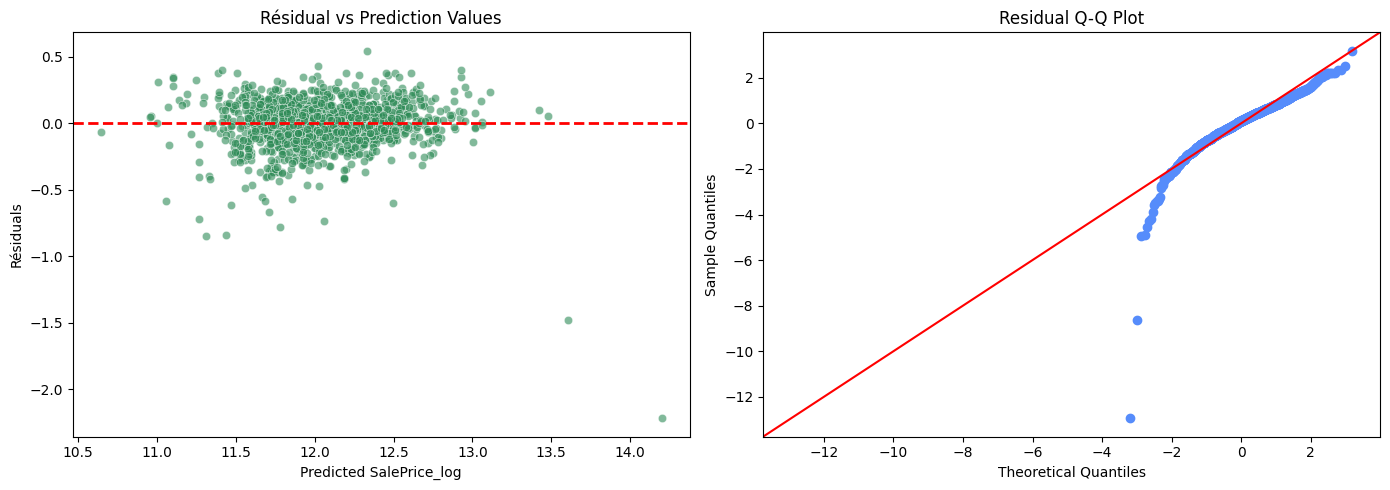


--- ANOVA with the Regression Model ---
                sum_sq      df           F        PR(>F)
GrLivArea    11.123375     1.0  376.254234  1.054342e-74
OverallQual   6.336657     1.0  214.340876  2.266723e-45
CentralAir    3.197974     1.0  108.173197  1.745444e-24
TotalBsmtSF   1.629345     1.0   55.113496  1.931483e-13
KitchenQual   1.507943     1.0   51.007008  1.451325e-12
FireplaceQu   1.315075     1.0   44.483144  3.638183e-11
BsmtQual      0.896106     1.0   30.311284  4.346189e-08
LotShape      0.772148     1.0   26.118325  3.638846e-07
ExterQual     0.425068     1.0   14.378141  1.556668e-04
Residual     42.867011  1450.0         NaN           NaN

--- Ridge & Lasso Comparison (Test Set) ---
Classical OLS (X_test) - RMSE: 0.1694 | R²: 0.8463
RIDGE                      - RMSE: 0.1730 | R²: 0.8396
LASSO                      - RMSE: 0.1729 | R²: 0.8398


In [39]:
# 1.Encoding
df_reg = train.copy()
text_features = ['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 'CentralAir', 'LotShape']
numeric_ordinal_features = ['OverallQual']
numeric_features = ['GrLivArea', 'TotalBsmtSF']


dict_values = {
    'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1,
    'Y': 1, 'N': 0,
    'NA': 0, 'None': 0,
    'Reg': 4, 'IR1' : 3, 'IR2' : 2, 'IR3' : 1,
}

# 1. Columns encoding
for col in text_features:
    df_reg[col] = df_reg[col].fillna(0)
    df_reg[col] = df_reg[col].replace(dict_values)
    df_reg[col] = pd.to_numeric(df_reg[col], errors='coerce')
    df_reg[col] = df_reg[col].fillna(0)

# 2. Missing values handling
df_reg['TotalBsmtSF'] = df_reg['TotalBsmtSF'].fillna(0)
df_reg['GrLivArea'] = df_reg['GrLivArea'].fillna(0)

# Variables regroupment
all_features = text_features + numeric_ordinal_features + numeric_features

# Final dataset creation (X and y)
df_reg = df_reg[all_features + ['SalePrice_log']].dropna() #Deleting the missing values


# 2. LINEAR REGRESSION MODEL (OLS)
# Updated formula
formula = 'SalePrice_log ~ ' + ' + '.join(all_features)
print(f"Regression Formula : {formula}\n")

# Model adjustment
ols_model = ols(formula, data=df_reg).fit()

# Results vizualisation
print(ols_model.summary())



# 3. RESIDUALS GRAPH
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Homoscedasticity (Residuals vs predicted values)
sns.scatterplot(x=ols_model.fittedvalues, y=ols_model.resid, ax=ax[0], alpha=0.6, color='seagreen')
ax[0].axhline(0, color='red', linestyle='--', lw=2)
ax[0].set_title('Résidual vs Prediction Values')
ax[0].set_xlabel('Predicted SalePrice_log')
ax[0].set_ylabel('Résiduals')

# Plot 2: Normality (Q-Q Plot)
sm.qqplot(ols_model.resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('Residual Q-Q Plot')

plt.tight_layout()
plt.show()



# 4. ANOVA WITH THE REGRESSION MODEL
anova_results = sm.stats.anova_lm(ols_model, typ=2)
print("\n--- ANOVA with the Regression Model ---")
print(anova_results.sort_values(by="PR(>F)", ascending=True))



# 5. RIDGE AND LASSO
X = df_reg[all_features]
y = df_reg['SalePrice_log']

# Split Train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge
ridge = Ridge(alpha=10.0).fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

# Lasso
lasso = Lasso(alpha=0.001).fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print("\n--- Ridge & Lasso Comparison (Test Set) ---")
print(f"Classical OLS (X_test) - RMSE: {np.sqrt(mean_squared_error(y_test, ols_model.predict(X_test))):.4f} | R²: {r2_score(y_test, ols_model.predict(X_test)):.4f}")
print(f"RIDGE                      - RMSE: {np.sqrt(mean_squared_error(y_test, pred_ridge)):.4f} | R²: {r2_score(y_test, pred_ridge):.4f}")
print(f"LASSO                      - RMSE: {np.sqrt(mean_squared_error(y_test, pred_lasso)):.4f} | R²: {r2_score(y_test, pred_lasso):.4f}")

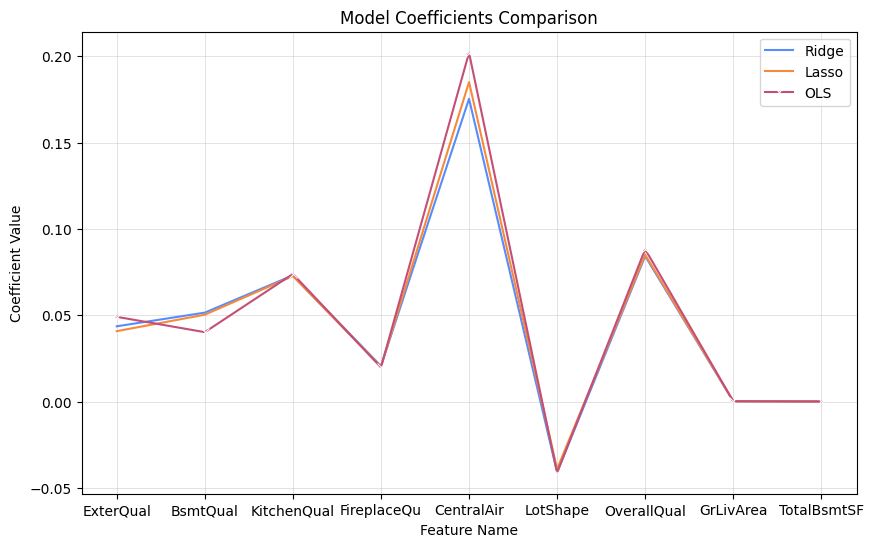

In [40]:
ols_coefs = [ols_model.params.get(col, 0) for col in X.columns]
coeffs_df = pd.DataFrame({
    'feature': X.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    "OLS": ols_coefs,
})

plt.figure(figsize=(10, 6))
sns.lineplot(data=coeffs_df, x='feature', y='Ridge', label='Ridge')
sns.lineplot(data=coeffs_df, x='feature', y='Lasso', label='Lasso')
sns.lineplot(data=coeffs_df, x='feature', y='OLS', label='OLS', marker='x')

plt.title("Model Coefficients Comparison")
plt.xlabel("Feature Name")
plt.ylabel("Coefficient Value")
plt.grid(True)
plt.show()

In [41]:
coeffs_df.sort_values(by='Lasso')

,feature,Ridge,Lasso,OLS
5,LotShape,-0.040847,-0.039007,-0.041162
8,TotalBsmtSF,0.000082,0.000083,0.000100
7,GrLivArea,0.000220,0.000221,0.000222
3,FireplaceQu,0.020641,0.020230,0.019858
0,ExterQual,0.043616,0.040808,0.049107
1,BsmtQual,0.051535,0.050340,0.040228
2,KitchenQual,0.073124,0.072681,0.073920
6,OverallQual,0.084276,0.085059,0.088286
4,CentralAir,0.175329,0.185047,0.202030


---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.

## Neural Network Structure

4 fully connected layers with a dropout rate of 0.5. ReLu has proven to be very effective as activation function, so a leaky_ReLu doesn't seem to be necessary. It has been added to prevent a possible vanishing gradient problem, which didn't happen but until now no real gain has been found in converting it into another ReLu.

The first layer's input size (shape) is set as dynamic instead of hard coding a number in fc1 so it doesn't need to be adjusted later in the code if needs change.

In [42]:
class Nn(nn.Module):
    def __init__(self, shape):
        super(Nn, self).__init__()
        self.fc1 = nn.Linear(in_features=shape, out_features=64) 
        self.fc2 = nn.Linear(in_features=64, out_features=50)
        self.fc4 = nn.Linear(in_features=50, out_features=35)
        self.fc3 = nn.Linear(in_features=35, out_features=1)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.leaky_relu(self.fc4(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

## Preprocessing data
-> Filling NA with 0 if numerical, with a string ("Missing") if categorical
-> Grouping the columns in numerical and categorical for preprocessing

NOTE: The original data set is reloaded once again to insure a cleaner preprocessing method with no data loss or modifications because of previous analysis.

In [43]:
# Importing original data set
train = data.copy()

# Separating features from target
X = train.drop(["SalePrice"], axis=1)

y = np.log(train["SalePrice"])

# columns separated by data types
num_col = X.select_dtypes(include=np.number).columns.tolist()
cat_col = X.select_dtypes(include=["object", "str"]).columns.tolist()

# NaN management
for col in num_col:
    X[col] = X[col].fillna(0)

for col in cat_col:
    X[col] = X[col].fillna("Missing").astype(str)

# OneHotEncoder appears sometimes to be changing the shape of the tensor
# this variable ensures the regularity of the shape.
cat_list = [X[col].unique().tolist() for col in cat_col]


INTERESTING OBSERVATION:
For the training of final model, no column is dropped other than SalePrice, so the NN can see all the data, but dropping some columns (even important ones) still results in a performing model.


X = train.drop(["SalePrice","LotConfig", "LandSlope","MoSold", "PoolArea", "ExterQual", "Neighborhood", 
"GrLivArea"], axis=1)
finally gets an impact on the final score.
Final performance:
RMSE: 0.12
  Mean Absolute Error:  £15,911
  Mean Absolute Percentage Error: 8.9%

Overall performance (Average across folds):
RMSE: 0.16
  Mean Absolute Error:  £19,326
  Mean Absolute Percentage Error: 11.1%

Up until the removal of GrLivArea, the NN was still doing an accurate prediction job (avg RMS 0.15). 

We didn't test this further, but it's a noticeable finding.

## Training

In [44]:
# Storing the results
fold_mae_results = []
fold_mape_results = []
fold_rmse_results = []
fold_r2 = []

# Some lines will be commented out to prevent the current model to be overwritten by mistake
# os.makedirs("saved_models_yousshouldntmesswith", exist_ok=True)


# Splitting data into folds for cross-validation 
splits = 5
kfold = KFold(n_splits=splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
    print(f"----FOLD {fold+1}---")
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # PREPROCESSOR: Applies the StandardScaler to the numerical features and the OneHotEncoder to the categorical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_col),
            ('cat', OneHotEncoder(categories=cat_list, handle_unknown='ignore', sparse_output=False), cat_col)
        ]
    )

    # Defining a new scaler for y
    scaler_y = StandardScaler()

    # train
    X_train_transformed = preprocessor.fit_transform(X_train_fold)
    y_train_transformed = scaler_y.fit_transform(np.array(y_train_fold).reshape(-1, 1))

    # test
    X_val_trans = preprocessor.transform(X_val_fold)
    y_val_trans = scaler_y.transform(np.array(y_val_fold).reshape(-1, 1))
    
    price_mean = scaler_y.mean_[0]
    price_std = scaler_y.scale_[0]

    # train and test into tensors
    X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_transformed, dtype=torch.float32)
    
    X_val_tensor = torch.tensor(X_val_trans, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_trans, dtype=torch.float32)
    
    # train and test tensors into tensors datasets and data loaders for mini-batch
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=35, shuffle=True)
    
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=35, shuffle=False)

    # ------- Model setup
    shape = X_train_tensor.shape[1]
    model = Nn(shape)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    #------.

    # -------------------------------------------------------------------------------- TRAINING 
    model.train()
    epochs = 50
    loss_history = []

    for epoch in range(epochs):
        running_loss = 0.0
        epoch_losses = []
        for x_batch, y_batch in train_loader:
            # gradient reset
            optimizer.zero_grad()
            # fwd pass
            predictions = model.forward(x_batch)
            loss = criterion(predictions, y_batch)
            epoch_losses.append(loss.item())

            # backward pass
            loss.backward()
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.detach().norm(2)
            # Adam
            optimizer.step()
            running_loss += loss.item()

        # tracking the loss 
        loss_history.append(np.mean(epoch_losses))
        if (epoch + 1) == 1 or (epoch + 1) == 50:
            print(f"Epoch {epoch + 1} | Loss: {running_loss / len(train)}")
    

    # UNCOMMENT HERE TO SAVE A NEW MODEL. This will overwrite the previous one,
    # please be sure to have a backup.
    # torch.save(model.state_dict(), f"saved_models_yousshouldntmesswith/fold{fold}.pt")

    # -------------------------------------------------------------------------------- MODEL EVALUATION            
    # Evaluating the model
    model.eval()

    with torch.no_grad():
        predictions = model(X_val_tensor)
        predictions_descaled = np.exp(predictions.numpy() * price_std + price_mean)

        y_val_real = np.exp(y_val_tensor.numpy() * price_std + price_mean)


        mae = mean_absolute_error(y_val_real,predictions_descaled)
        mape = mean_absolute_percentage_error(y_val_real,predictions_descaled)*100
        RMSE = root_mean_squared_log_error(y_val_real,predictions_descaled)
        r2 = r2_score(y_val_real,predictions_descaled)

        fold_mae_results.append(mae)
        fold_mape_results.append(mape)
        fold_rmse_results.append(RMSE)
        fold_r2.append(r2)


print(f"\nLast performance:")
print(f"RMSE: {RMSE:.2f}")
print(f"R2: {r2:.2f}")
print(f"  Mean Absolute Error:  £{mae:,.0f}")
print(f"  Mean Absolute Percentage Error: {mape:.1f}%")

print(f"\nOverall performance (Average across folds):")
print(f"RMSE: {np.mean(fold_rmse_results):.3f}")
print(f"R2: {np.mean(fold_r2):.2f}")
print(f"  Mean Absolute Error:  £{np.mean(fold_mae_results):,.0f}")
print(f"  Mean Absolute Percentage Error: {np.mean(fold_mape_results):.1f}%")

----FOLD 1---
Epoch 1 | Loss: 0.021577435282811728
Epoch 50 | Loss: 0.0018214270931808916
----FOLD 2---
Epoch 1 | Loss: 0.019906599880897834
Epoch 50 | Loss: 0.0018226471576482466
----FOLD 3---
Epoch 1 | Loss: 0.02036628202624517
Epoch 50 | Loss: 0.0015938073600808235
----FOLD 4---
Epoch 1 | Loss: 0.020603603308331477
Epoch 50 | Loss: 0.0017616112065845973
----FOLD 5---
Epoch 1 | Loss: 0.019469542944268003
Epoch 50 | Loss: 0.0019098410306319798

Last performance:
RMSE: 0.11
R2: 0.93
  Mean Absolute Error:  £13,262
  Mean Absolute Percentage Error: 7.9%

Overall performance (Average across folds):
RMSE: 0.148
R2: 0.52
  Mean Absolute Error:  £17,096
  Mean Absolute Percentage Error: 9.8%


In [45]:
print(fold_rmse_results)
print(fold_r2)

[0.1420169026552029, 0.14742403290851167, 0.20043786156659313, 0.1418978187908231, 0.1095836927454489]
[0.88212069459194, 0.7860575701910404, -0.8516165593869807, 0.8556336796767309, 0.933913732761296]


The scores' histories show an interesting fold where the model suddently fails. There are a few big outliers in the dataset and probably one or more ended up in that validation set.

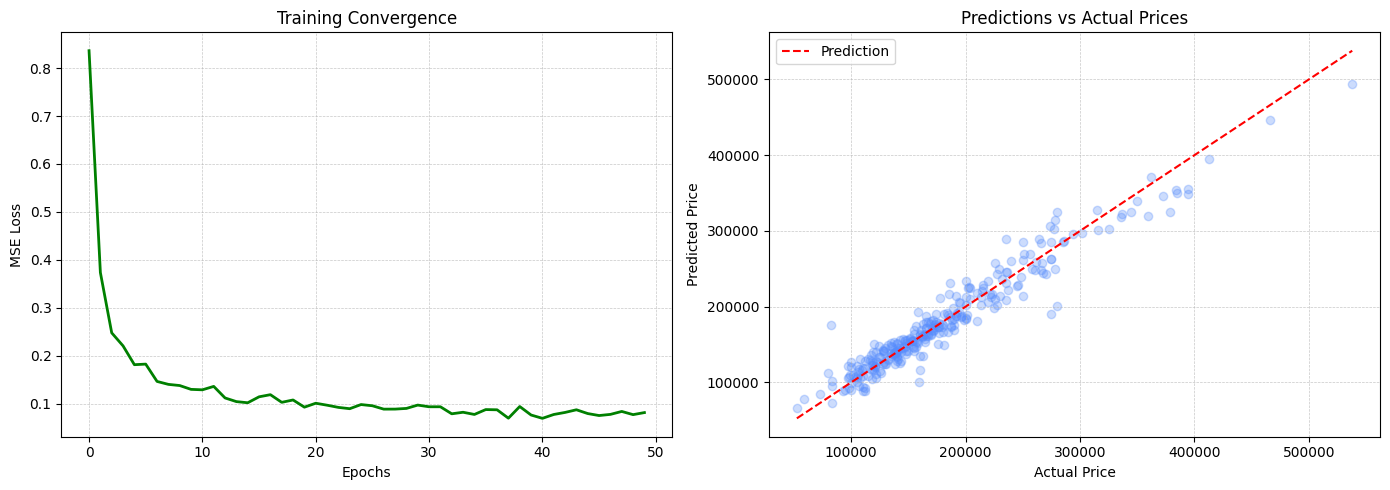

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history, color='green', linewidth=2)
axes[0].set_title("Training Convergence")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, linestyle='--', alpha=0.7)


axes[1].scatter(y_val_real, predictions_descaled, alpha=0.3)
axes[1].plot([y_val_real.min(), y_val_real.max()],
             [y_val_real.min(), y_val_real.max()], 'r--', label="Prediction")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Predictions vs Actual Prices")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

We notice the most significant loss reduction occurs between the first and 8th-9th epoch. Then the loss is still decreasing but at a slower rate from the 9th to the 30th epoch and even less until the 50th epoch. Compare to the training with 100 epochs, this is more relevant and efficient.

With the visualisation of the predictions vs actual price (with the red line representing the predicted value), we observe that :
- the 0 to 300000 range contains most of the observations in the data set and are really close to the red line. There are 4 observations positioned further from the line
- the 300000 to the end, there are fewer data points and they are on average more distant from the reference line.

Overall the predictions are close to the actual prices.

## Using the model on new data

In [47]:


test_df = pd.read_csv('data/test.csv')

def test(data):
# preprocessing
    X_test = data
    for col in num_col:
        X_test[col] = X_test[col].fillna(0)
    for col in cat_col:
        X_test[col] = X_test[col].fillna("Missing").astype(str)

    X_test_transformed = preprocessor.transform(X_test)
    X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
    


    all_test_predictions = []

    with torch.no_grad():
        for fold in range(splits):
            fold_model = Nn(X_test_tensor.shape[1])
            fold_model.load_state_dict(torch.load(f"./saved_models_4/fold{fold}.pt"))
            fold_model.eval()
            
            pred = fold_model(X_test_tensor)
            
            pred_descaled = np.exp(pred.numpy() * price_std + price_mean)
            all_test_predictions.append(pred_descaled)

    all_test_predictions = np.array(all_test_predictions)
    final_predictions = np.mean(all_test_predictions, axis=0).flatten()

    submission = pd.DataFrame({
        "Id": data["Id"],
        "SalePrice": final_predictions
    })
    return submission



In [48]:
# results = test(test_df)
# results.to_csv("submission_yousshouldntmesswith.csv", index=False)
